In [1]:
from google.colab import drive
import json
import os

# Mount drive
drive.mount('/content/drive')

# Define paths
csv_data_path = '/content/drive/MyDrive/DSA210-Project/data/'

Mounted at /content/drive


In [18]:
import pandas as pd
df = pd.read_csv(csv_data_path + 'pre_cross_val_ml_dataset.csv')
print(df.head())

          Pokemon         Ability_1 Ability_2 Ability_3  Hazard  Pivot  Setup  \
0        koraidon  Orichalcum Pulse       NaN       NaN       0      1      1   
1  zacian-crowned    Intrepid Sword       NaN       NaN       0      0      1   
2          kyogre           Drizzle       NaN       NaN       0      0      1   
3          arceus         Multitype       NaN       NaN       0      0      1   
4           ho-oh       Regenerator  Pressure       NaN       0      0      0   

   Recovery  Utility  Priority  TypeDefScore  TypeOffScore  SpeedTier  \
0         0        0         0           4.0          15.5          1   
1         0        0         0          36.5          13.0          1   
2         0        1         0          12.0           6.0          3   
3         1        1         1          11.0          -0.5          2   
4         1        1         0          16.0          14.0          3   

   PhysBulk  SpeBulk  AtkToSpaRatio  WastedStatRatio   Tier  
0     11500 

In [29]:
from sklearn.model_selection import train_test_split

tier_map = {
    "Ubers": 0,
    "OU": 1,
    "UU": 2,
    "RU": 3,
    "NU": 4,
    "PU": 5,
    "ZU": 6
}

y = df['Tier'].map(tier_map)
X = df.drop(columns=['Tier'])

X_train_cv, X_holdout, y_train_cv, y_holdout = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train_cv = X_train_cv.copy()
X_holdout = X_holdout.copy()
y_train_cv = y_train_cv.copy()
y_holdout = y_holdout.copy()

In [30]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_results = cross_validate(
    baseline_model,
    X_train_cv,
    y_train_cv,
    cv=5,
    scoring=['accuracy', 'f1_macro']
)

print(f"Baseline Accuracy: {baseline_results['test_accuracy'].mean():.4f}")
print(f"Baseline F1 (Macro): {baseline_results['test_f1_macro'].mean():.4f}")

Baseline Accuracy: 0.4167
Baseline F1 (Macro): 0.0840


#XGBoost Attempt

#Hyper Parameter Tuning

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.0 MB/s eta 0:00:00


In [21]:
import optuna
print("Optuna Version", optuna.__version__)

Optuna Version 4.8.0


In [22]:
impactful_abilities = ['Intimidate', 'Magic Guard', 'Prankster', 'Drizzle', 'Drought', 'Huge Power', 'Magic Bounce', 'Snow Warning', 'Guts',
                       'Regenerator', 'Speed Boost', 'Unaware', 'Technician'
                       ]
print(impactful_abilities)

['Intimidate', 'Magic Guard', 'Prankster', 'Drizzle', 'Drought', 'Huge Power', 'Magic Bounce', 'Snow Warning', 'Guts', 'Regenerator', 'Speed Boost', 'Unaware', 'Technician']


In [25]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def objective_gpu(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 10, 600),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "device": "cuda",
        "eval_metric": "mlogloss",
        "random_state": 42,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):
        X_train, X_test = X_train_cv.iloc[tr].copy(), X_train_cv.iloc[va].copy()
        y_train, y_test = y_train_cv.iloc[tr], y_train_cv.iloc[va]


        ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']

        abilities_in_fold = set(X_train[ability_cols].values.ravel())

        abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_fold]

        for ability in abilities_to_encode:
            X_train[f"{ability}"] = X_train[ability_cols].eq(ability).any(axis=1).astype(int)
            X_test[f"{ability}"] = X_test[ability_cols].eq(ability).any(axis=1).astype(int)

        X_train_final = X_train.drop(columns=['Pokemon'] + ability_cols)
        X_test_final = X_test.drop(columns=['Pokemon'] + ability_cols)

        X_train_np = X_train_final.to_numpy(dtype=np.float32)
        X_test_np = X_test_final.to_numpy(dtype=np.float32)
        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()

        model = xgb.XGBClassifier(**param)
        model.fit(X_train_np, y_train_np)

        preds_np = model.predict(X_test_np)

        scores.append(f1_score(y_test_np, preds_np, average='macro'))

    return float(np.mean(scores))

In [26]:
study = optuna.create_study(study_name="xgboost_study_gpu", direction="maximize")
study.optimize(objective_gpu, n_trials=35, show_progress_bar=True, n_jobs=-1)

[I 2026-05-16 10:00:52,691] A new study created in memory with name: xgboost_study_gpu


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2026-05-16 10:00:59,687] Trial 1 finished with value: 0.2053907559512978 and parameters: {'max_depth': 7, 'learning_rate': 0.05474017583535597, 'n_estimators': 172, 'subsample': 0.9719056804841626, 'colsample_bytree': 0.7533623130191025, 'min_child_weight': 15, 'gamma': 2.0733398175428785}. Best is trial 1 with value: 0.2053907559512978.
[I 2026-05-16 10:01:04,966] Trial 2 finished with value: 0.18129464779279197 and parameters: {'max_depth': 5, 'learning_rate': 0.04315571313404955, 'n_estimators': 111, 'subsample': 0.5804618309980645, 'colsample_bytree': 0.910326361780928, 'min_child_weight': 16, 'gamma': 4.992555818696005}. Best is trial 1 with value: 0.2053907559512978.
[I 2026-05-16 10:01:14,473] Trial 0 finished with value: 0.18573437923191188 and parameters: {'max_depth': 9, 'learning_rate': 0.02943826270382413, 'n_estimators': 396, 'subsample': 0.9978258166438625, 'colsample_bytree': 0.8712822535765276, 'min_child_weight': 5, 'gamma': 2.2989973624770355}. Best is trial 1 with

In [27]:
best_params = study.best_params
print(f"\nBest parameters: {best_params}")


Best parameters: {'max_depth': 6, 'learning_rate': 0.09166205290505422, 'n_estimators': 520, 'subsample': 0.7526085278611265, 'colsample_bytree': 0.7387290107386232, 'min_child_weight': 1, 'gamma': 0.031485100895693036}


In [28]:
import optuna.visualization as vis

display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

#Model Training

In [31]:
import xgboost as xgb
from sklearn.metrics import f1_score, accuracy_score

# Train using train + val then evaluate on X_holdout i.e. test
ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']
abilities_in_train_set = set(X_train_cv[ability_cols].values.ravel())

abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_train_set]

for ability in abilities_to_encode:
    X_train_cv[f"{ability}"] = X_train_cv[ability_cols].eq(ability).any(axis=1).astype(int)
    X_holdout[f"{ability}"] = X_holdout[ability_cols].eq(ability).any(axis=1).astype(int)

X_train_final = X_train_cv.drop(columns=['Pokemon'] + ability_cols)
X_test_final = X_holdout.drop(columns=['Pokemon'] + ability_cols)

model_xgb = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.09166205290505422,
    n_estimators=520,
    subsample=0.7526085278611265,
    colsample_bytree=0.7387290107386232,
    min_child_weight=1,
    gamma=0.031485100895693036,
    objective="multi:softprob",
    random_state=42
)

model_xgb.fit(X_train_final, y_train_cv)

preds = model_xgb.predict(X_test_final)
train_preds = model_xgb.predict(X_train_final)

train_acc = accuracy_score(y_train_cv, train_preds)
train_f1 = f1_score(y_train_cv, train_preds, average='macro')

acc = accuracy_score(y_holdout, preds)
f1 = f1_score(y_holdout, preds, average='macro')

print(f"Train Set Accuracy: {train_acc:.4f}")
print(f"Train Set F1 Score: {train_f1:.4f}")

print(f"\nTest Set Accuracy: {acc:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")

Train Set Accuracy: 0.9973
Train Set F1 Score: 0.9958

Test Set Accuracy: 0.4731
Test Set F1 Score: 0.2782


In [33]:
import matplotlib.pyplot as plt

def feature_importance_graph(trained_model, features):
  # 1. Get feature importance
  importances = trained_model.feature_importances_
  indices = np.argsort(importances)

  # 2. Plot it
  plt.figure(figsize=(10, 8))
  plt.title("Feature Importances")
  plt.barh(range(len(indices)), importances[indices], color='b', align='center')
  plt.yticks(range(len(indices)), [features[i] for i in indices])
  plt.xlabel('Relative Importance')
  plt.show()

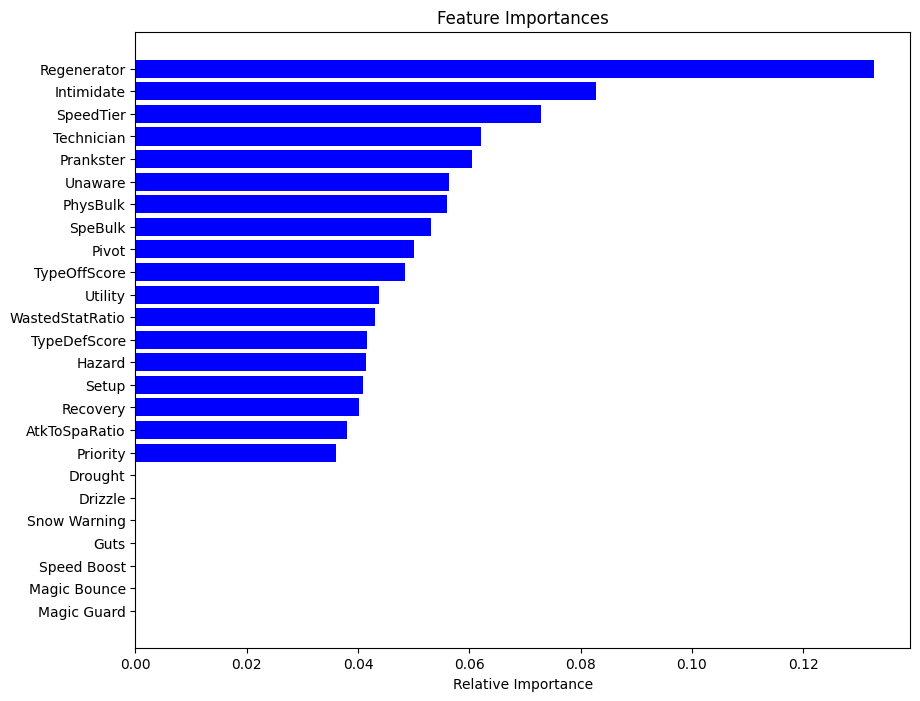

In [34]:
feature_importance_graph(model_xgb, X_train_final.columns)

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def draw_conf_maxtrix(true_labels, predicted_labels):
  # Create the confusion matrix
  cm = confusion_matrix(true_labels, predicted_labels)

  # Set up the display
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_map.keys())

  # Plotting
  fig, ax = plt.subplots(figsize=(10, 10))
  disp.plot(cmap='Blues', ax=ax, values_format='d')
  plt.title('Tier Prediction Confusion Matrix')
  plt.show()

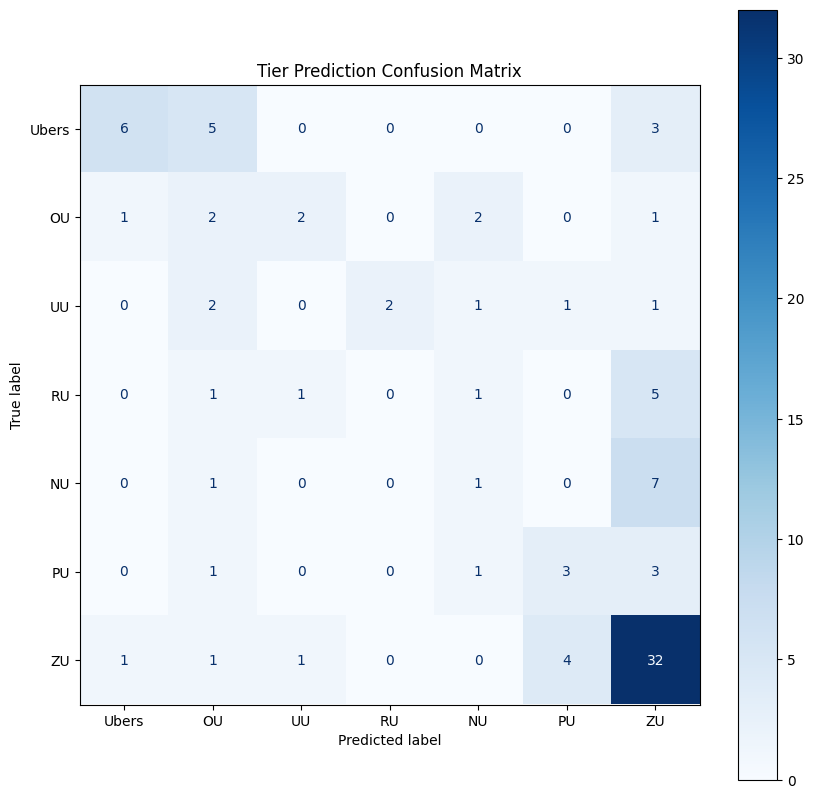

In [36]:
draw_conf_maxtrix(y_holdout, preds)

#SVM Attempt

#Hyperparameter Tuning

In [37]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.svm import SVC

numerical_cols = ['TypeDefScore', 'TypeOffScore', 'SpeedTier', 'PhysBulk', 'SpeBulk', 'AtkToSpaRatio', 'WastedStatRatio']

def objective_svm(trial):
    param = {
        "C": trial.suggest_float("C", 0.001, 1000, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear", "poly"]),
        "gamma": trial.suggest_float("gamma", 0.0001, 10, log=True),
        "class_weight": "balanced"
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):
        X_train, X_test = X_train_cv.iloc[tr].copy(), X_train_cv.iloc[va].copy()
        y_train, y_test = y_train_cv.iloc[tr], y_train_cv.iloc[va]

        ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']
        abilities_in_fold = set(X_train[ability_cols].values.ravel())
        abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_fold]

        for ability in abilities_to_encode:
            X_train[f"{ability}"] = X_train[ability_cols].eq(ability).any(axis=1).astype(int)
            X_test[f"{ability}"] = X_test[ability_cols].eq(ability).any(axis=1).astype(int)

        X_train_final = X_train.drop(columns=['Pokemon'] + ability_cols)
        X_test_final = X_test.drop(columns=['Pokemon'] + ability_cols)

        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_final[numerical_cols])
        X_test_num_scaled = scaler.transform(X_test_final[numerical_cols])

        categorical_features = [col for col in X_train_final.columns if col not in numerical_cols]
        X_train_bin = X_train_final[categorical_features].to_numpy()
        X_test_bin = X_test_final[categorical_features].to_numpy()

        X_train_prepared = np.hstack([X_train_num_scaled, X_train_bin])
        X_test_prepared = np.hstack([X_test_num_scaled, X_test_bin])

        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()

        model = SVC(**param)
        model.fit(X_train_prepared, y_train_np)

        preds = model.predict(X_test_prepared)
        scores.append(f1_score(y_test_np, preds, average='macro'))

    return float(np.mean(scores))

In [42]:
study_svm = optuna.create_study(study_name="svm_study", direction='maximize')
study_svm.optimize(objective_svm, n_trials=35, show_progress_bar=True, n_jobs=-1)

[I 2026-05-16 10:34:21,570] A new study created in memory with name: svm_study


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2026-05-16 10:34:22,260] Trial 1 finished with value: 0.04904270141791657 and parameters: {'C': 7.655357321032022, 'kernel': 'poly', 'gamma': 0.00021408090871213485}. Best is trial 1 with value: 0.04904270141791657.
[I 2026-05-16 10:34:22,334] Trial 0 finished with value: 0.025663016283171323 and parameters: {'C': 0.0013453175807496812, 'kernel': 'rbf', 'gamma': 0.0005034371377243478}. Best is trial 1 with value: 0.04904270141791657.
[I 2026-05-16 10:34:23,011] Trial 2 finished with value: 0.061627735431522015 and parameters: {'C': 0.006331532462040483, 'kernel': 'rbf', 'gamma': 0.00011985829586676519}. Best is trial 2 with value: 0.061627735431522015.
[I 2026-05-16 10:34:23,056] Trial 3 finished with value: 0.30487358857991326 and parameters: {'C': 127.45291304179614, 'kernel': 'poly', 'gamma': 1.0465747809820525}. Best is trial 3 with value: 0.30487358857991326.
[I 2026-05-16 10:34:23,619] Trial 4 finished with value: 0.276240021927246 and parameters: {'C': 0.04491280749215149, 'k

In [43]:
best_params_svm = study_svm.best_params
print(f"\nBest parameters: {best_params_svm}")


Best parameters: {'C': 0.2229654734741685, 'kernel': 'poly', 'gamma': 0.9849349645346741}


In [44]:
import optuna.visualization as vis

display(vis.plot_param_importances(study_svm))
display(vis.plot_optimization_history(study_svm))

#Model Training

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score

numerical_cols = ['TypeDefScore', 'TypeOffScore', 'SpeedTier', 'PhysBulk', 'SpeBulk', 'AtkToSpaRatio', 'WastedStatRatio']

# Train using train + val then evaluate on X_holdout i.e. test
ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']
abilities_in_train_set = set(X_train_cv[ability_cols].values.ravel())

abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_train_set]

for ability in abilities_to_encode:
    X_train_cv[f"{ability}"] = X_train_cv[ability_cols].eq(ability).any(axis=1).astype(int)
    X_holdout[f"{ability}"] = X_holdout[ability_cols].eq(ability).any(axis=1).astype(int)

X_train_final = X_train_cv.drop(columns=['Pokemon'] + ability_cols)
X_test_final = X_holdout.drop(columns=['Pokemon'] + ability_cols)

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_final[numerical_cols])
X_test_num_scaled = scaler.transform(X_test_final[numerical_cols])

categorical_features = [col for col in X_train_final.columns if col not in numerical_cols]
X_train_bin = X_train_final[categorical_features].to_numpy()
X_test_bin = X_test_final[categorical_features].to_numpy()

X_train_prepared = np.hstack([X_train_num_scaled, X_train_bin])
X_test_prepared = np.hstack([X_test_num_scaled, X_test_bin])

y_train_np = y_train_cv.to_numpy()
y_test_np = y_holdout.to_numpy()

model_svm = SVC(
    C=0.2229654734741685,
    kernel='poly',
    gamma=0.9849349645346741,
    class_weight='balanced'
)
model_svm.fit(X_train_prepared, y_train_np)

preds = model_svm.predict(X_test_prepared)
train_preds = model_svm.predict(X_train_prepared)

train_acc = accuracy_score(y_train_cv, train_preds)
train_f1 = f1_score(y_train_cv, train_preds, average='macro')

acc = accuracy_score(y_holdout, preds)
f1 = f1_score(y_holdout, preds, average='macro')

print(f"Train Set Accuracy: {train_acc:.4f}")
print(f"Train Set F1 Score: {train_f1:.4f}")

print(f"\nTest Set Accuracy: {acc:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")

Train Set Accuracy: 1.0000
Train Set F1 Score: 1.0000

Test Set Accuracy: 0.3978
Test Set F1 Score: 0.2704


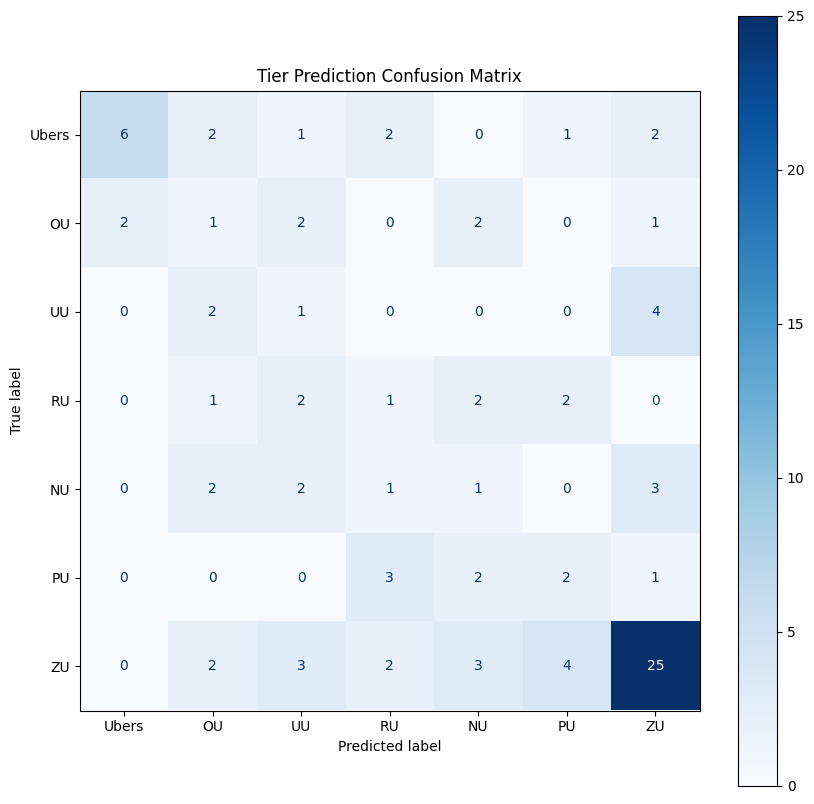

In [49]:
draw_conf_maxtrix(y_holdout, preds)